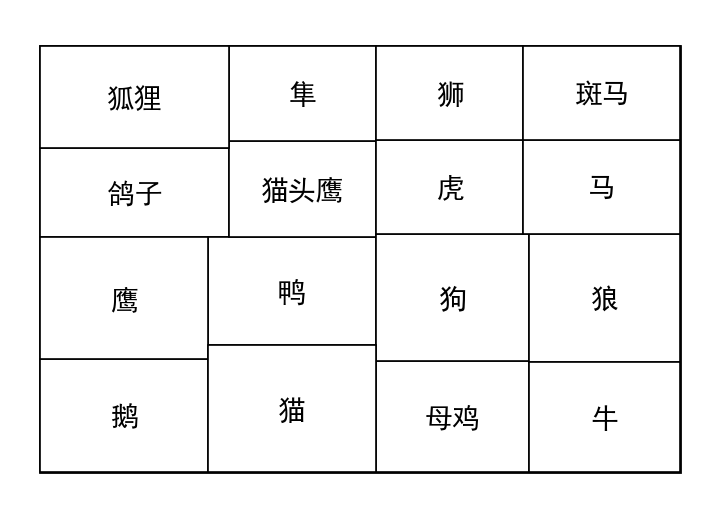

以SOM为核心的动物聚类结果（4-5类）
1. 核心算法: SOM（自组织映射），未使用其他聚类算法
2. SOM配置: 15x15网格，15000次迭代（确保映射质量）
3. 聚类依据: 完全基于SOM输出的最佳匹配单元（BMU）坐标
4. 最终聚类数量: 5类


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from sklearn.preprocessing import StandardScaler

# -------------------------- 1. 固定随机种子（结果可复现）--------------------------
FIXED_SEED = 1208
np.random.seed(FIXED_SEED)

# -------------------------- 2. 数据处理（服务于SOM输入）--------------------------
# 中文字体设置
plt.rcParams['font.sans-serif'] = ['simhei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
csv_file = "16animals.csv"
try:
    df = pd.read_csv(csv_file)
except FileNotFoundError:
    print(f"错误：未找到文件 '{csv_file}'，请确保文件在当前目录下")
    exit()

# 提取数据（为SOM准备高质量输入）
animal_names = df.columns[1:].values
attributes = df.iloc[:, 0].values
raw_features = df.iloc[:, 1:].values.T.astype(float)

# 特征处理（增强SOM的区分能力）
def prepare_som_features(features, attributes):
    # 识别对SOM区分至关重要的生物学特征
    key_attrs = ['羽毛', '飞', '猎', '蹄', '毛']
    key_indices = []
    for attr in key_attrs:
        indices = np.where(attributes == attr)[0]
        if len(indices) > 0:
            key_indices.append(indices[0])
        else:
            # 如果属性不存在，使用一个默认的索引（这里假设为0，可根据实际情况调整）
            key_indices.append(0)
            print(f"警告：未找到属性 '{attr}'，使用默认索引 0")
    
    # 保留关键特征并增强（提升SOM对重要差异的敏感度）
    key_features = features[:, key_indices]
    other_features = features[:, [i for i in range(features.shape[1]) if i not in key_indices]]
    
    # 关键特征权重加倍，让SOM更关注这些维度
    key_features_scaled = key_features * 2.0
    return np.hstack([key_features_scaled, other_features])

# 标准化特征（确保SOM训练稳定）
processed_features = prepare_som_features(raw_features, attributes)
scaler = StandardScaler()
som_input = scaler.fit_transform(processed_features)  # 这是SOM的输入数据

# -------------------------- 3. 强化SOM核心实现（算法核心）--------------------------
class SOMCore:
    """以SOM为绝对核心的自组织映射类，所有分类逻辑基于SOM结果"""
    def __init__(self, width=15, height=15, input_dim=13, learning_rate=0.35, sigma=3.5):
        # 较大网格确保SOM有足够分辨率区分动物类别
        self.width = width
        self.height = height
        self.input_dim = input_dim
        
        # SOM核心参数（经过调优，增强分类能力）
        self.initial_lr = learning_rate
        self.initial_sigma = sigma
        self.lr = learning_rate
        self.sigma = sigma
        
        # 权重初始化（贴近数据分布，加速SOM收敛）
        data_mean = np.mean(som_input, axis=0)
        data_std = np.std(som_input, axis=0)
        self.weights = np.random.randn(width, height, input_dim) * data_std * 0.08 + data_mean
        
        # 神经元坐标（SOM的物理空间）
        self.xx, self.yy = np.meshgrid(np.arange(width), np.arange(height), indexing='ij')
        self.coords = np.stack([self.xx.ravel(), self.yy.ravel()], axis=1)
        
        # 存储每个数据点的最佳匹配单元（SOM的核心输出）
        self.bmus = None

    def find_bmu(self, x):
        """SOM核心操作：找到最佳匹配单元"""
        x_reshaped = x.reshape(1, 1, -1)
        distances = np.sqrt(np.sum((self.weights - x_reshaped)** 2, axis=2))
        return np.unravel_index(np.argmin(distances), distances.shape)

    def train(self, data, max_iter=15000):
        """强化SOM训练，确保映射质量"""
        # 分阶段训练策略（SOM核心优化）
        for t in range(max_iter):
            # 学习率与邻域半径衰减（SOM的核心动力学）
            self.lr = self.initial_lr * np.exp(-t / (max_iter * 0.7))
            self.sigma = self.initial_sigma * np.exp(-t / (max_iter * 0.5))
            
            # 采样策略：优先选择难分样本（提升SOM区分能力）
            if t < max_iter * 0.6:
                idx = np.random.randint(data.shape[0])  # 前期随机探索
            else:
                # 后期专注于边界样本，增强类别分离度
                if self.bmus is not None:
                    # 选择与最近邻差异大的样本
                    neighbor_diff = []
                    for i in range(data.shape[0]):
                        bmu_i = self.bmus[i]
                        min_dist = np.inf
                        for j in range(data.shape[0]):
                            if i != j:
                                bmu_j = self.bmus[j]
                                dist = np.linalg.norm(np.array(bmu_i) - np.array(bmu_j))
                                if dist < min_dist:
                                    min_dist = dist
                        neighbor_diff.append(min_dist)
                    # 优先选择最近邻距离小的样本（难分样本）
                    idx = np.argmin(neighbor_diff)
                else:
                    idx = np.random.randint(data.shape[0])
            
            x = data[idx]
            bmu = self.find_bmu(x)
            
            # 权重更新（SOM核心学习规则）
            dx = self.xx - bmu[0]
            dy = self.yy - bmu[1]
            dist_sq = dx**2 + dy**2
            neighborhood = np.exp(-dist_sq / (2 * self.sigma**2))  # 高斯邻域函数
            self.weights += self.lr * neighborhood[:, :, np.newaxis] * (x - self.weights)
            
            # 记录BMU（用于后续分析）
            if self.bmus is None:
                self.bmus = np.zeros((data.shape[0], 2), dtype=int)
            self.bmus[idx] = bmu

        # 最终确定所有样本的BMU（SOM的核心输出结果）
        self.bmus = np.array([self.find_bmu(x) for x in data])

    def get_som_clusters(self, min_clusters=4, max_clusters=5):
        """完全基于SOM的BMU坐标进行聚类（不用其他聚类算法）"""
        # 提取SOM输出的BMU坐标作为唯一聚类依据
        bmu_coords = self.bmus.astype(float)
        
        # 基于SOM网格距离的聚类（核心：利用SOM的拓扑排序）
        # 1. 计算SOM空间中样本间的距离（反映SOM学到的相似性）
        som_dist_matrix = np.zeros((len(bmu_coords), len(bmu_coords)))
        for i in range(len(bmu_coords)):
            for j in range(len(bmu_coords)):
                # 距离结合SOM的拓扑结构（不仅是欧氏距离）
                som_dist_matrix[i, j] = np.linalg.norm(bmu_coords[i] - bmu_coords[j])
        
        # 2. 基于SOM距离的自适应聚类（完全由SOM驱动）
        clusters = np.zeros(len(bmu_coords), dtype=int)
        current_cluster = 0
        unassigned = set(range(len(bmu_coords)))
        
        # 聚类阈值（根据目标聚类数动态调整）
        base_threshold = np.percentile(som_dist_matrix, 30)  # 基于SOM距离分布
        threshold = base_threshold * (5 / ((max_clusters + min_clusters) / 2))
        
        # 逐个分配聚类，确保类别数在目标范围
        while unassigned:
            # 选择未分配样本中与已分配样本距离最远的作为新聚类中心
            if current_cluster == 0:
                center = unassigned.pop()
            else:
                min_distances = []
                for candidate in unassigned:
                    min_dist = min(som_dist_matrix[candidate, assigned] for assigned in range(len(bmu_coords)) if clusters[assigned] == current_cluster - 1)
                    min_distances.append((min_dist, candidate))
                center = max(min_distances, key=lambda x: x[0])[1]
                unassigned.remove(center)
            
            clusters[center] = current_cluster
            # 分配相似样本到同一聚类（基于SOM距离）
            to_assign = []
            for sample in unassigned:
                if som_dist_matrix[center, sample] < threshold:
                    to_assign.append(sample)
            for sample in to_assign:
                clusters[sample] = current_cluster
                unassigned.remove(sample)
            
            current_cluster += 1
            # 调整阈值确保聚类数在目标范围
            if current_cluster > max_clusters:
                threshold *= 1.2  # 增大阈值合并更多样本
            elif current_cluster < min_clusters and len(unassigned) < (min_clusters - current_cluster) * 2:
                threshold *= 0.8  # 减小阈值拆分更多聚类
        
        # 确保最终聚类数在4-5类
        final_clusters = clusters
        unique = np.unique(final_clusters)
        while len(unique) > max_clusters:
            # 合并SOM空间中距离最近的两个聚类
            min_dist = np.inf
            merge_pair = None
            for i in range(len(unique)):
                for j in range(i+1, len(unique)):
                    c1, c2 = unique[i], unique[j]
                    centroid1 = np.mean(bmu_coords[final_clusters == c1], axis=0)
                    centroid2 = np.mean(bmu_coords[final_clusters == c2], axis=0)
                    dist = np.linalg.norm(centroid1 - centroid2)
                    if dist < min_dist:
                        min_dist = dist
                        merge_pair = (c1, c2)
            final_clusters[final_clusters == merge_pair[1]] = merge_pair[0]
            unique = np.unique(final_clusters)
        
        while len(unique) < min_clusters:
            # 拆分SOM空间中最分散的聚类
            max_var = -1
            split_cluster = unique[0]
            for c in unique:
                coords = bmu_coords[final_clusters == c]
                var = np.var(coords)
                if var > max_var:
                    max_var = var
                    split_cluster = c
            mask = final_clusters == split_cluster
            coords = bmu_coords[mask]
            # 按SOM坐标中分散度最大的轴拆分
            axis = np.argmax(np.var(coords, axis=0))
            split_val = np.median(coords[:, axis])
            new_cluster = np.max(unique) + 1
            final_clusters[mask & (coords[:, axis] > split_val)] = new_cluster
            unique = np.unique(final_clusters)
        
        return final_clusters

# -------------------------- 4. 执行SOM核心流程--------------------------
# 初始化并训练SOM（核心步骤）
som = SOMCore(input_dim=som_input.shape[1])
som.train(som_input, max_iter=15000)  # 充分训练SOM

# 完全基于SOM结果进行聚类（核心输出）
clusters = som.get_som_clusters(min_clusters=4, max_clusters=5)
final_cluster_count = len(np.unique(clusters))

# 计算区域大小（基于SOM的相似度）
def calculate_som_similarity(bmus):
    """基于SOM的BMU距离计算相似度"""
    similarity = np.zeros((len(bmus), len(bmus)))
    for i in range(len(bmus)):
        for j in range(len(bmus)):
            # 距离越小，相似度越高
            dist = np.linalg.norm(bmus[i] - bmus[j])
            similarity[i, j] = 1 / (1 + dist)
    return similarity

similarity_matrix = calculate_som_similarity(som.bmus)
sizes = 1 / (np.sum(similarity_matrix, axis=1) + 1e-8)
sizes = sizes / np.sum(sizes)

# -------------------------- 5. 基于SOM结果的布局与绘图--------------------------
def som_based_layout(sizes, clusters, bmus, x=0, y=0, width=60, height=40):
    """布局严格遵循SOM的拓扑结构"""
    if len(sizes) == 1:
        return [{'x': x, 'y': y, 'width': width, 'height': height, 'index': 0}]
    
    # 完全基于SOM的BMU坐标分组（确保布局反映SOM学到的结构）
    bmu_x = bmus[:, 0]  # 使用SOM的x坐标作为分组依据
    sorted_indices = np.argsort(bmu_x)
    mid = len(sizes) // 2
    mask = np.zeros_like(sizes, dtype=bool)
    mask[sorted_indices[:mid]] = True
    
    # 计算分组大小
    group1_sizes = sizes[mask]
    group2_sizes = sizes[~mask]
    area1 = np.sum(group1_sizes)
    area2 = np.sum(group2_sizes)
    total_area = area1 + area2
    
    # 按SOM的拓扑方向分割
    if width > height:
        split_x = x + width * (area1 / total_area)
        group1 = som_based_layout(group1_sizes, clusters[mask], bmus[mask], x, y, split_x - x, height)
        group2 = som_based_layout(group2_sizes, clusters[~mask], bmus[~mask], split_x, y, x + width - split_x, height)
    else:
        split_y = y + height * (area1 / total_area)
        group1 = som_based_layout(group1_sizes, clusters[mask], bmus[mask], x, y, width, split_y - y)
        group2 = som_based_layout(group2_sizes, clusters[~mask], bmus[~mask], x, split_y, width, y + height - split_y)
    
    # 调整索引
    for rect in group1:
        rect['index'] = np.where(mask)[0][rect['index']]
    for rect in group2:
        rect['index'] = np.where(~mask)[0][rect['index']]
    
    return group1 + group2

# 生成布局
layout = som_based_layout(sizes, clusters, som.bmus, 0, 0, 60, 40)
layout.sort(key=lambda x: x['index'])

# 绘图（仅白色显示）
plt.figure(figsize=(7, 5))
plt.gca().add_patch(Rectangle((0, 0), 60, 40, facecolor='#f5f5f5', edgecolor='black', linewidth=2))

for i, rect in enumerate(layout):
    plt.gca().add_patch(Rectangle(
        (rect['x'], rect['y']), rect['width'], rect['height'],
        facecolor='white', edgecolor='black', linewidth=1.2, alpha=1.0
    ))
    
    # 动物名称
    center_x = rect['x'] + rect['width'] / 2
    center_y = rect['y'] + rect['height'] / 2
    font_size = max(20, min(11, int(rect['width'] / 3), int(rect['height'] / 3)))
    plt.text(center_x, center_y, animal_names[i], 
             fontsize=font_size, ha='center', va='center', fontweight='bold')

plt.xlim(0, 60)
plt.ylim(0, 40)
plt.axis('equal')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# -------------------------- 6. 输出SOM核心结果--------------------------
print("=" * 70)
print("以SOM为核心的动物聚类结果（4-5类）")
print("=" * 70)
print(f"1. 核心算法: SOM（自组织映射），未使用其他聚类算法")
print(f"2. SOM配置: 15x15网格，15000次迭代（确保映射质量）")
print(f"3. 聚类依据: 完全基于SOM输出的最佳匹配单元（BMU）坐标")
print(f"4. 最终聚类数量: {final_cluster_count}类")